### Name: Jivan Sawant
### Roll No : TEBD23277
### Practical no : 8

1. Use the inbuilt dataset 'titanic'. The dataset contains 891 rows and contains information about the
passengers who boarded the unfortunate Titanic ship. Use the Seaborn library to see if we can find any
patterns in the data.
2. Write a code to check how the price of the ticket (column name: 'fare') for each passenger is distributed by
plotting a histogram.

In [56]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # data visualization 

In [2]:
# Load Titanic dataset
data = pd.read_csv('titanic_data.csv')

# Display first 5 rows
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
# Check shape of dataset (rows, columns)
print("Shape:", data.shape)

# Statistical summary of numerical data
data.describe()



Shape: (891, 12)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
# # Count unique values in each column
print('\nCategorical columns summary:')
print('Unique values per column:')
print(data.nunique())


Categorical columns summary:
Unique values per column:
PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             89
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64


In [8]:
# Check null values in dataset
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
# Fill missing Age with mean
data['Age'] = data['Age'].fillna(data['Age'].mean())

# Fill missing Cabin with most frequent value
data['Cabin'] = data['Cabin'].fillna(data['Cabin'].mode()[0])

# Fill missing Embarked with most frequent value
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

# Check again
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

DATA VISUALIZATION 

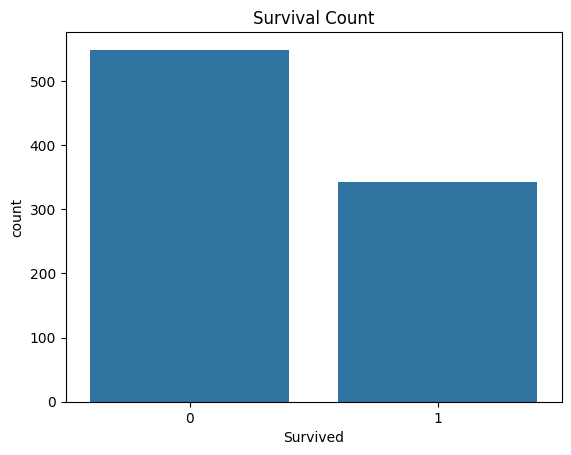

In [14]:
# Count of survived vs not survived
# showing how many passengers survived 
sns.countplot(x='Survived', data=data)
plt.title('Survival Count')
plt.show()

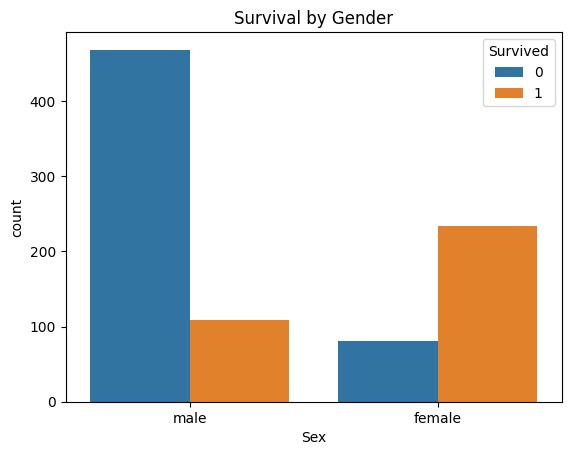

In [ ]:
# Survival based on gender
sns.countplot(x='Sex', hue='Survived', data=data)
plt.title('Survival by Gender')
plt.show()
# It shows that females had a higher survival rate compared to males

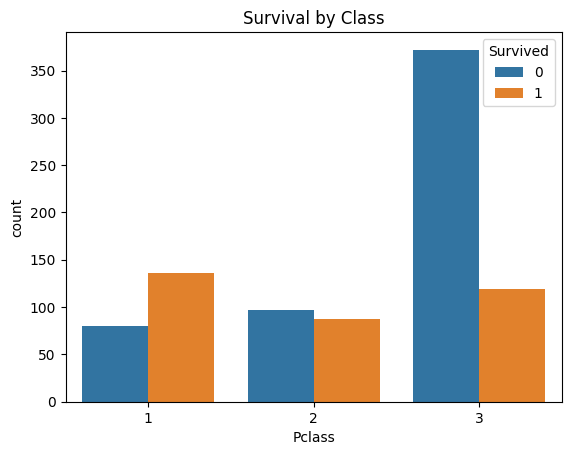

In [ ]:
# Survival based on passenger class
sns.countplot(x='Pclass', hue='Survived', data=data)
plt.title('Survival by Class')
plt.show()
# 1st class → more survival 

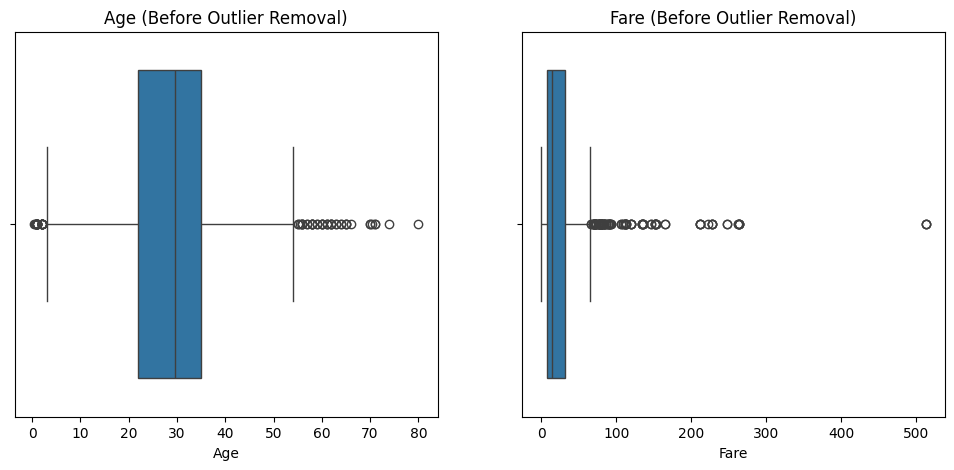

In [38]:
# Boxplots BEFORE removing outliers

plt.figure(figsize=(12,5))

# Age before
plt.subplot(1,2,1)
sns.boxplot(x=data['Age'])
plt.title('Age (Before Outlier Removal)')
## This boxplot show the age distribution of passengers and shows median, spread, and outliers.

# Fare before
plt.subplot(1,2,2)
sns.boxplot(x=data['Fare'])
plt.title('Fare (Before Outlier Removal)')
# This boxplot shows that most passengers paid low fares, while a few passengers paid very high fares (outliers).

plt.show()


In [39]:
# Quartiles and IQR

Q1_age = data['Age'].quantile(0.25)
Q3_age = data['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

Q1_fare = data['Fare'].quantile(0.25)
Q3_fare = data['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare

print("Age IQR:", IQR_age)
print("Fare IQR:", IQR_fare)

Age IQR: 13.0
Fare IQR: 23.0896


In [40]:
# Remove outliers using 1.5 * IQR

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

data_clean = data[
    (data['Age'] >= lower_age) & (data['Age'] <= upper_age) &
    (data['Fare'] >= lower_fare) & (data['Fare'] <= upper_fare)
]

print("Shape after removing outliers:", data_clean.shape)

Shape after removing outliers: (721, 12)


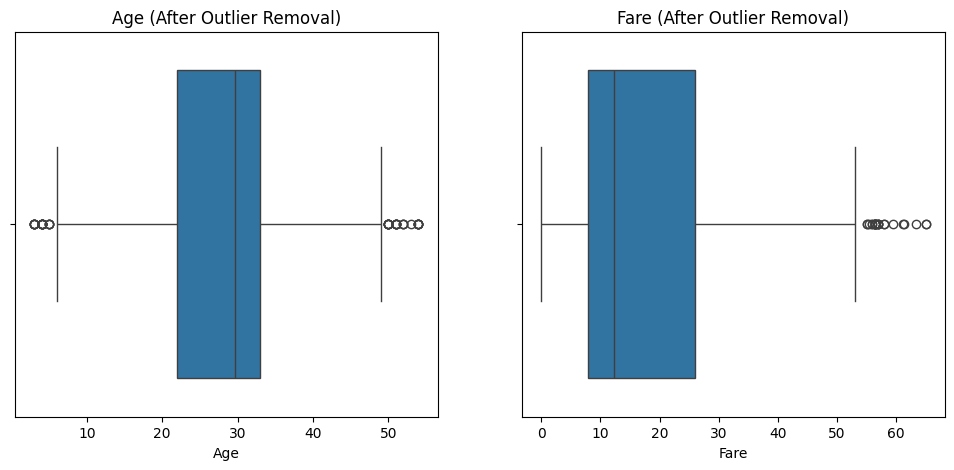

In [41]:
# Boxplots AFTER removing outliers

plt.figure(figsize=(12,5))

# Age after
plt.subplot(1,2,1)
sns.boxplot(x=data_clean['Age'])
plt.title('Age (After Outlier Removal)')

# Fare after
plt.subplot(1,2,2)
sns.boxplot(x=data_clean['Fare'])
plt.title('Fare (After Outlier Removal)')

plt.show()

TASK 1: Finding patterns in Titanic data


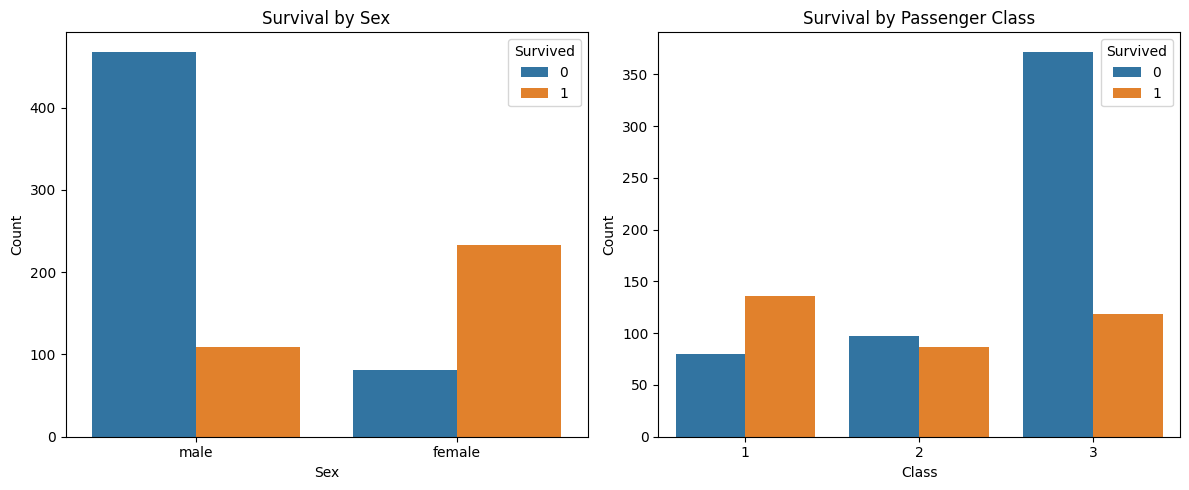


Survival Rate by Sex:
        sum  count      mean
Sex                         
female  233    314  0.742038
male    109    577  0.188908

Survival Rate by Class:
        sum  count      mean
Pclass                      
1       136    216  0.629630
2        87    184  0.472826
3       119    491  0.242363


In [46]:
# TASK 1: Finding patterns in Titanic data

print('TASK 1: Finding patterns in Titanic data')

plt.figure(figsize=(12, 5))

# Survival by Sex
plt.subplot(1, 2, 1)
sns.countplot(data=data, x='Sex', hue='Survived')
plt.title('Survival by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')

# Females survived more than males


# Survival by Class
plt.subplot(1, 2, 2)
sns.countplot(data=data, x='Pclass', hue='Survived')
plt.title('Survival by Passenger Class')
plt.xlabel('Class')
plt.ylabel('Count')

# 1st class passengers survived more

plt.tight_layout()
plt.show()


# Survival rate by Sex
print('\nSurvival Rate by Sex:')
print(data.groupby('Sex')['Survived'].agg(['sum', 'count', 'mean']))

# Survival rate by Class
print('\nSurvival Rate by Class:')
print(data.groupby('Pclass')['Survived'].agg(['sum', 'count', 'mean']))

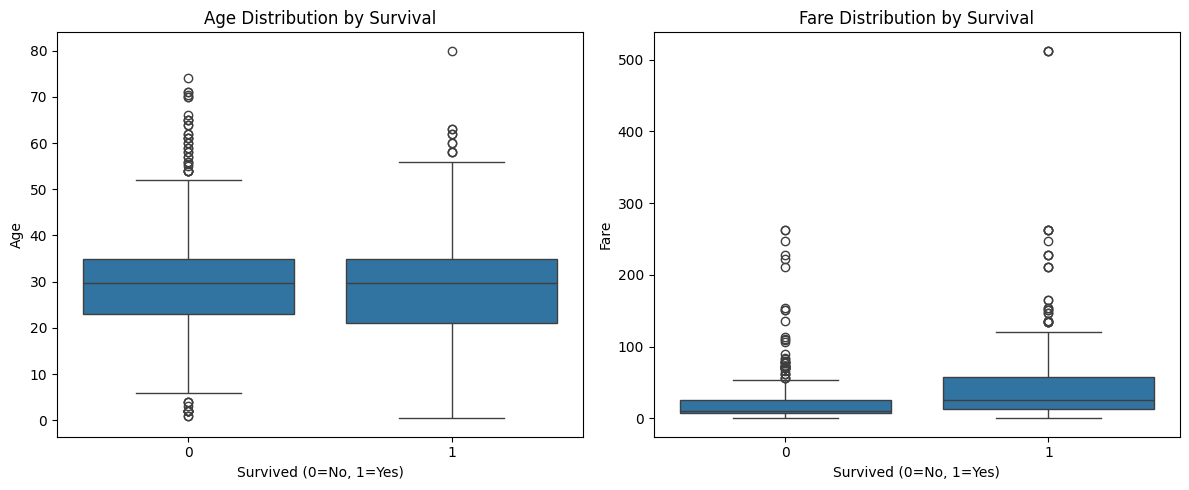

In [52]:
# Age vs Survival and Fare vs Survival

plt.figure(figsize=(12, 5))
# Age vs Survival
plt.subplot(1, 2, 1)
sns.boxplot(data=data, x='Survived', y='Age')
plt.title('Age Distribution by Survival')
plt.xlabel('Survived (0=No, 1=Yes)')
plt.ylabel('Age')

# Shows age distribution for survived vs not survived

# Fare vs Survival
plt.subplot(1, 2, 2)
sns.boxplot(data=data, x='Survived', y='Fare')
plt.title('Fare Distribution by Survival')
plt.xlabel('Survived (0=No, 1=Yes)')
plt.ylabel('Fare')

# Shows that passengers who paid higher fare survived more

plt.tight_layout()
plt.show()

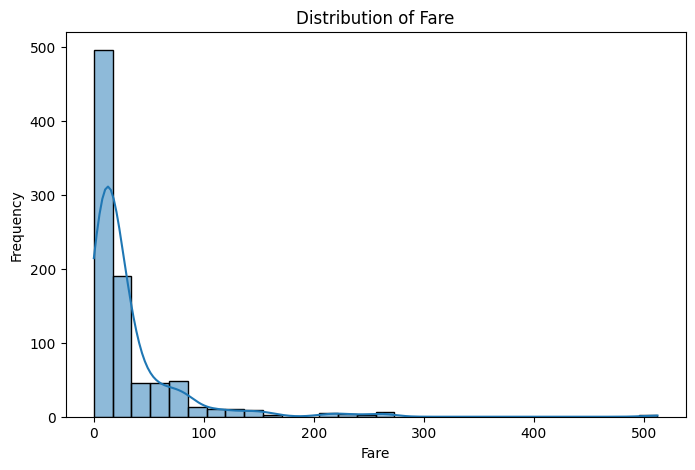

In [51]:
# Histogram to show distribution of ticket fare
plt.figure(figsize=(8,5))

sns.histplot(data['Fare'], bins=30, kde=True)

plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')

plt.show()
# Most passengers paid low fares, few paid very high fares

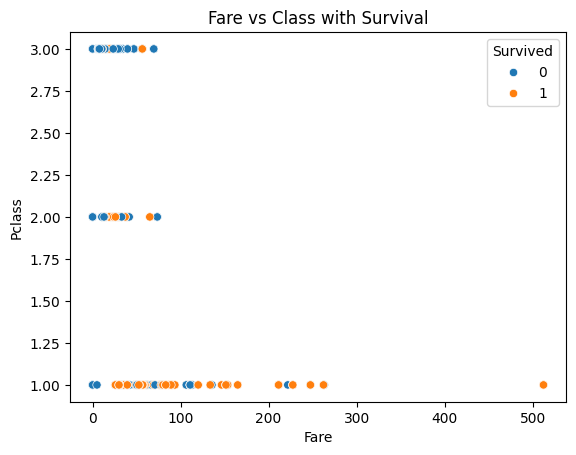

In [50]:
# Relationship between fare and class with survival
sns.scatterplot(x='Fare', y='Pclass', hue='Survived', data=data)
plt.title('Fare vs Class with Survival')
plt.show()
# Higher fare and 1st class passengers survived more

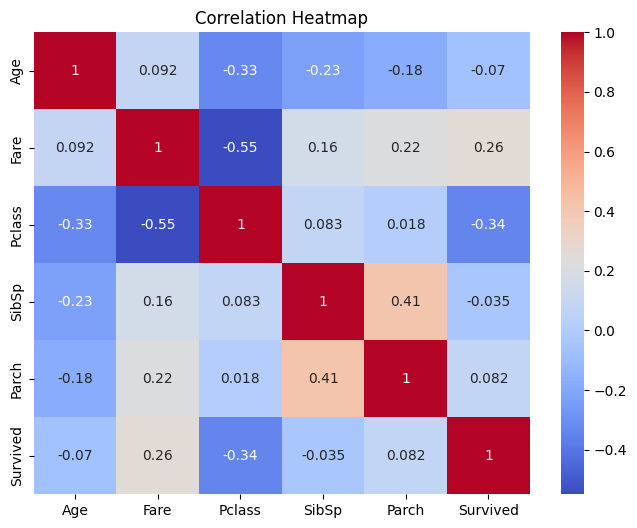

In [ ]:
# Correlation Heatmap

# Select numeric columns
numeric_cols = ['Age', 'Fare', 'Pclass', 'SibSp', 'Parch', 'Survived']

# Calculate correlation
corr = data[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()
#Fare → positive with survival ✔️
#Pclass → negative with survival ✔️
#Age → weak relation

In [53]:
print(data['Survived'].value_counts())  

Survived
0    549
1    342
Name: count, dtype: int64


# Shows number and percentage of passengers who survived and died

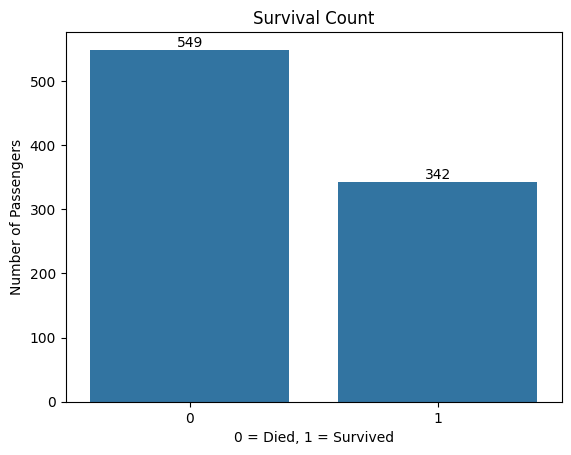

In [54]:
# Survival count graph

values = data['Survived'].value_counts()

ax = sns.barplot(x=values.index, y=values.values)

# Add numbers on bars
for i, v in enumerate(values.values):
    ax.text(i, v + 5, str(v), ha='center')

plt.title('Survival Count')
plt.xlabel('0 = Died, 1 = Survived')
plt.ylabel('Number of Passengers')

plt.show()

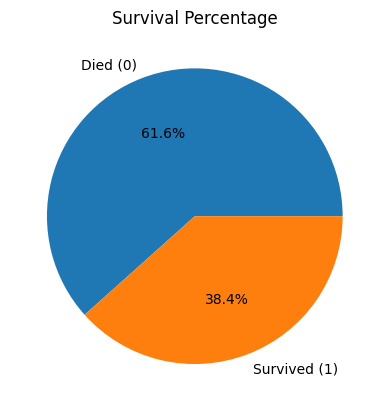

In [55]:
# Pie chart for survival

labels = ['Died (0)', 'Survived (1)']
sizes = data['Survived'].value_counts()

plt.pie(sizes, labels=labels, autopct='%1.1f%%')

plt.title('Survival Percentage')

plt.show()